## Neural Collaborative Filtering (NCF)

In [40]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style('whitegrid')
np.random.seed(42)
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed(42)

In [20]:
df = pd.read_csv('../../data/children_products/clildren_product_cleaned.csv')
print(f"Размер: {df.shape}")
df.head()

Размер: (610913, 16)


,Дата,НомерЗаказаНаСайте,МетодДоставки,Группа2,Группа3,Тип,Отменено,Количество,Цена,Статус,Гео,Маржа,СуммаУслуг,Телефон_new,ID_SKU,МетодДоставки_Групп
0,2017-03-01 11:41:00,3998972_TR,Курьерская,КРУПНОГАБАРИТНЫЙ ТОВАР,КОЛЯСКИ,КГТ,Нет,1,680.0,Возврат,Москва,508.00,0,55574854-48574951555577,ID9010020114553,Курьерская
1,2017-03-01 12:22:00,3999117_TR,Магазины,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,379.0,Доставлен,Регионы,169.20,0,55575453-56535648535679,IDL00028974351,Магазины
2,2017-03-01 12:31:00,3999122_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ ДЕВОЧЕК,ИГРУШКИ,Нет,1,3325.0,Доставлен,Регионы,2176.00,0,55574950-57515657535772,IDL00038573351,Магазины
3,2017-03-01 03:06:00,3999363_TR,Курьерская,"ТЕКСТИЛЬ, ТРИКОТАЖ",ОДЕЖДА ДЛЯ НОВОРОЖДЕННЫХ (0-2 лет),ОДЕЖДА,Нет,1,330.0,Доставлен,Москва,163.04,0,55574851-55545249535475,IDL00034303856,Курьерская
4,2017-03-01 11:38:00,3999411_TR,Магазины,ИГРУШКИ,ИГРУШКИ ДЛЯ РАЗВИТИЯ МАЛЫШЕЙ,ИГРУШКИ,Нет,1,199.0,Доставлен,Регионы,120.00,0,55574854-56495552515179,IDL00035791553,Магазины


In [21]:
df.info()
print(df['Статус'].value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 610913 entries, 0 to 610912
Data columns (total 16 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Дата                 610913 non-null  object 
 1   НомерЗаказаНаСайте   610913 non-null  object 
 2   МетодДоставки        610913 non-null  object 
 3   Группа2              610913 non-null  object 
 4   Группа3              610913 non-null  object 
 5   Тип                  610913 non-null  object 
 6   Отменено             610913 non-null  object 
 7   Количество           610913 non-null  int64  
 8   Цена                 610913 non-null  float64
 9   Статус               610913 non-null  object 
 10  Гео                  610913 non-null  object 
 11  Маржа                610913 non-null  float64
 12  СуммаУслуг           610913 non-null  int64  
 13  Телефон_new          610913 non-null  object 
 14  ID_SKU               610913 non-null  object 
 15  МетодДоставки_Гру

In [22]:
df_filtered = df[(df['Статус'] == 'Доставлен') & (df['Отменено'] == 'Нет')].copy()
print(f"После фильтрации: {df_filtered.shape}")

После фильтрации: (420857, 16)


In [23]:
df_filtered = df_filtered.dropna(subset=['Телефон_new', 'ID_SKU', 'Дата'])
df_filtered['Дата'] = pd.to_datetime(df_filtered['Дата'], errors='coerce')
df_filtered = df_filtered.dropna(subset=['Дата'])
print(f"Диапазон дат: {df_filtered['Дата'].min()} - {df_filtered['Дата'].max()}")

Диапазон дат: 2017-03-01 00:03:00 - 2017-04-30 23:58:00


In [24]:
n_users = df_filtered['Телефон_new'].nunique()
n_items = df_filtered['ID_SKU'].nunique()
print(f"Пользователей: {n_users:,}, Товаров: {n_items:,}")

Пользователей: 87,194, Товаров: 65,067


In [25]:
interactions = df_filtered.groupby(['Телефон_new', 'ID_SKU']).size().reset_index(name='count')
print(f"Уникальных пар: {len(interactions):,}")
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()
interactions['user_id'] = user_encoder.fit_transform(interactions['Телефон_new'])
interactions['item_id'] = item_encoder.fit_transform(interactions['ID_SKU'])
user_id_to_phone = dict(zip(interactions['user_id'], interactions['Телефон_new']))
item_id_to_sku = dict(zip(interactions['item_id'], interactions['ID_SKU']))

Уникальных пар: 392,517


In [26]:
interactions_with_date = df_filtered.merge(
    interactions[['Телефон_new', 'ID_SKU', 'user_id', 'item_id', 'count']],
    on=['Телефон_new', 'ID_SKU'], how='inner'
).sort_values('Дата')
split_date = interactions_with_date['Дата'].quantile(0.8)
print(f"Дата разделения: {split_date}")
train_data = interactions_with_date[interactions_with_date['Дата'] < split_date].copy()
test_data = interactions_with_date[interactions_with_date['Дата'] >= split_date].copy()
print(f"Train: {len(train_data):,}, Test: {len(test_data):,}")

Дата разделения: 2017-04-18 20:23:00
Train: 336,668, Test: 84,189


In [27]:
train_interactions = train_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
test_interactions = test_data.groupby(['user_id', 'item_id'])['count'].sum().reset_index()
train_users = set(train_interactions['user_id'].unique())
test_users = set(test_interactions['user_id'].unique())
print(f"Train users: {len(train_users):,}, Test users: {len(test_users):,}")

Train users: 73,184, Test users: 21,097


Генерация негативных примеров

In [28]:
def generate_negative_samples(interactions_df, n_items, num_negatives=4):
    user_items = interactions_df.groupby('user_id')['item_id'].apply(set).to_dict()
    negative_samples = []
    for _, row in interactions_df.iterrows():
        user_id = row['user_id']
        negatives_count = 0
        attempts = 0
        while negatives_count < num_negatives and attempts < num_negatives * 10:
            neg_item = np.random.randint(0, n_items)
            attempts += 1
            if neg_item not in user_items.get(user_id, set()):
                negative_samples.append({'user_id': user_id, 'item_id': neg_item, 'label': 0})
                negatives_count += 1
    return pd.DataFrame(negative_samples)

n_items_total = len(item_encoder.classes_)
train_negatives = generate_negative_samples(train_interactions, n_items_total, num_negatives=4)
train_positives = train_interactions[['user_id', 'item_id']].copy()
train_positives['label'] = 1
train_samples = pd.concat([train_positives, train_negatives], ignore_index=True)
train_samples = train_samples.sample(frac=1, random_state=42).reset_index(drop=True)
print(f"Позитивных: {len(train_positives):,}, Негативных: {len(train_negatives):,}")

Позитивных: 316,556, Негативных: 1,266,224


In [32]:
class NCFDataset(Dataset):
    def __init__(self, user_ids, item_ids, labels):
        self.user_ids = torch.LongTensor(user_ids)
        self.item_ids = torch.LongTensor(item_ids)
        self.labels = torch.FloatTensor(labels)
    def __len__(self): 
        return len(self.user_ids)
    def __getitem__(self, idx): 
        return self.user_ids[idx], self.item_ids[idx], self.labels[idx]

train_dataset = NCFDataset(train_samples['user_id'].values, train_samples['item_id'].values, train_samples['label'].values)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
print(f"Dataset: {len(train_dataset):,}, Батчей: {len(train_loader):,}")

Dataset: 1,582,780, Батчей: 6,183


In [ ]:
class NCF(nn.Module):
    def __init__(self, num_users, num_items, emb_dim=64, hidden_dim=64):
        super().__init__()
        self.user_embedding = nn.Embedding(num_users, emb_dim)
        self.item_embedding = nn.Embedding(num_items, emb_dim)

        self.fc1 = nn.Linear(emb_dim * 2, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, 1)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_embedding.weight, std=0.01)
        nn.init.normal_(self.item_embedding.weight, std=0.01)
        nn.init.xavier_uniform_(self.fc1.weight)
        nn.init.constant_(self.fc1.bias, 0)
        nn.init.xavier_uniform_(self.fc2.weight)
        nn.init.constant_(self.fc2.bias, 0)

    def forward(self, user_ids, item_ids):
        u = self.user_embedding(user_ids)
        v = self.item_embedding(item_ids)
        x = torch.cat([u, v], dim=-1)
        h = torch.relu(self.fc1(x))
        logits = self.fc2(h).squeeze(-1)
        y_hat = torch.sigmoid(logits)
        return y_hat
    
num_users = len(user_encoder.classes_)
num_items = len(item_encoder.classes_)

model = NCF(num_users, num_items, emb_dim=64, hidden_dim=64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Device: {device}, Params: {sum(p.numel() for p in model.parameters()):,}")



Device: cpu, Params: 9,753,025


In [ ]:
from tqdm.notebook import tqdm

criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10
train_losses = []

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", unit="batch")

    for user_ids, item_ids, labels in loop:
        user_ids = user_ids.to(device)
        item_ids = item_ids.to(device)
        labels = labels.to(device)

        predictions = model(user_ids, item_ids)
        loss = criterion(predictions, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        # обновляем подпись бара текущим loss
        loop.set_postfix(loss=loss.item())

    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: avg_loss={avg_loss:.4f}")

Epoch 1/10:   0%|          | 0/6183 [00:00<?, ?batch/s]

Epoch 1: avg_loss=0.3470


Epoch 2/10:   0%|          | 0/6183 [00:00<?, ?batch/s]

Epoch 2: avg_loss=0.2892


Epoch 3/10:   0%|          | 0/6183 [00:00<?, ?batch/s]

...

Epoch 8: avg_loss=0.0464


Epoch 9/10:   0%|          | 0/6183 [00:00<?, ?batch/s]

Epoch 9: avg_loss=0.0293


Epoch 10/10:   0%|          | 0/6183 [00:00<?, ?batch/s]

Epoch 10: avg_loss=0.0188


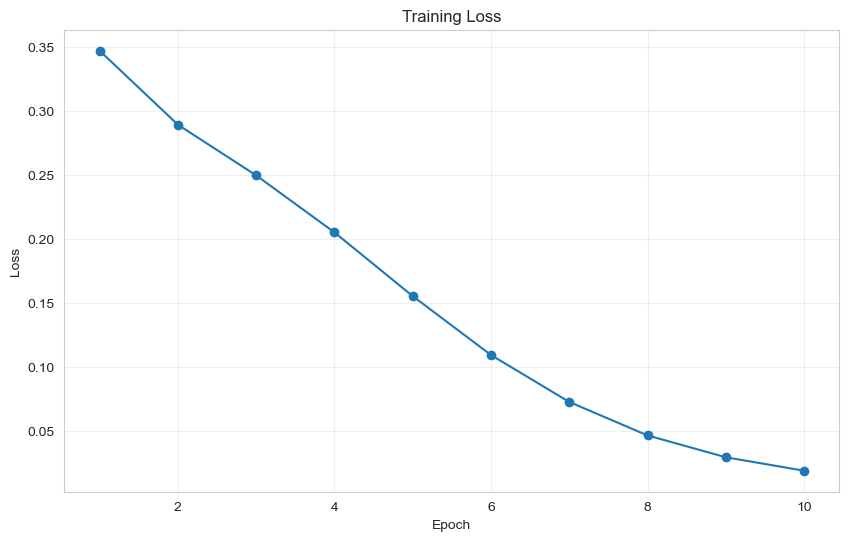

In [35]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, num_epochs + 1), train_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True, alpha=0.3)
plt.show()

In [42]:
def get_recommendations_ncf(model, user_id, train_interactions, n_items, k=10, device="cpu"):
    model.eval()

    # товары пользователя в train
    user_history = train_interactions.loc[train_interactions["user_id"] == user_id, "item_id"]
    bought_items = set(user_history.to_numpy())  # тут ок, это pandas → numpy, не torch

    # все товары
    items = torch.arange(n_items, device=device, dtype=torch.long)
    users = torch.full_like(items, fill_value=user_id)

    with torch.no_grad():
        scores = model(users, items)          # (n_items,)
        scores = scores.detach().cpu()        # остаёмся в torch

    # фильтруем уже купленное
    candidates_idx = []
    candidates_scores = []
    for i in range(n_items):
        if i not in bought_items:
            candidates_idx.append(i)
            candidates_scores.append(scores[i].item())

    # находим top-k по torch, без numpy
    if len(candidates_idx) == 0:
        return [], []

    scores_tensor = torch.tensor(candidates_scores)
    topk_scores, topk_pos = torch.topk(scores_tensor, k=min(k, len(candidates_idx)))

    item_ids = [candidates_idx[pos] for pos in topk_pos.tolist()]
    item_scores = topk_scores.tolist()
    return item_ids, item_scores


In [43]:
def precision_at_k(recommended, relevant, k):
    if k == 0:
        return 0.0
    rec_k = set(recommended[:k])
    rel = set(relevant)
    if not rec_k:
        return 0.0
    return len(rec_k & rel) / len(rec_k)


def recall_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    rec_k = set(recommended[:k])
    return len(rec_k & rel) / len(rel)


def map_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    score = 0.0
    hits = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            hits += 1.0
            score += hits / (i + 1.0)
    return score / min(len(rel), k)


def ndcg_at_k(recommended, relevant, k):
    rel = set(relevant)
    if not rel:
        return 0.0
    dcg = 0.0
    for i, item in enumerate(recommended[:k]):
        if item in rel:
            dcg += 1.0 / np.log2(i + 2)
    idcg = sum(1.0 / np.log2(i + 2) for i in range(min(len(rel), k)))
    return dcg / idcg if idcg > 0 else 0.0


In [ ]:
def evaluate_model(model, train_interactions, test_interactions, n_items,
                   k_values=(5, 10, 20), device="cpu"):
    test_user_items = (
        test_interactions.groupby("user_id")["item_id"]
        .apply(list)
        .to_dict()
    )

    train_users = set(train_interactions["user_id"].unique())
    eval_users = [u for u in test_user_items.keys() if u in train_users]

    metrics = {
        k: {"precision": [], "recall": [], "map": [], "ndcg": []}
        for k in k_values
    }

    for user_id in eval_users:
        rec_items, _ = get_recommendations_ncf(
            model, user_id, train_interactions, n_items,
            k=max(k_values), device=device
        )
        relevant_items = test_user_items[user_id]

        for k in k_values:
            p = precision_at_k(rec_items, relevant_items, k)
            r = recall_at_k(rec_items, relevant_items, k)
            m = map_at_k(rec_items, relevant_items, k)
            n = ndcg_at_k(rec_items, relevant_items, k)

            metrics[k]["precision"].append(p)
            metrics[k]["recall"].append(r)
            metrics[k]["map"].append(m)
            metrics[k]["ndcg"].append(n)

    avg_metrics = {
        k: {
            "precision": float(np.mean(v["precision"])) if v["precision"] else 0.0,
            "recall":    float(np.mean(v["recall"]))    if v["recall"] else 0.0,
            "map":       float(np.mean(v["map"]))       if v["map"] else 0.0,
            "ndcg":      float(np.mean(v["ndcg"]))      if v["ndcg"] else 0.0,
        }
        for k, v in metrics.items()
    }
    return avg_metrics


In [45]:
results = evaluate_model(
    model,
    train_interactions,
    test_interactions,
    n_items=num_items,
    k_values=[5, 10, 20],
    device=device
)

Оценка на 7,087 пользователях...


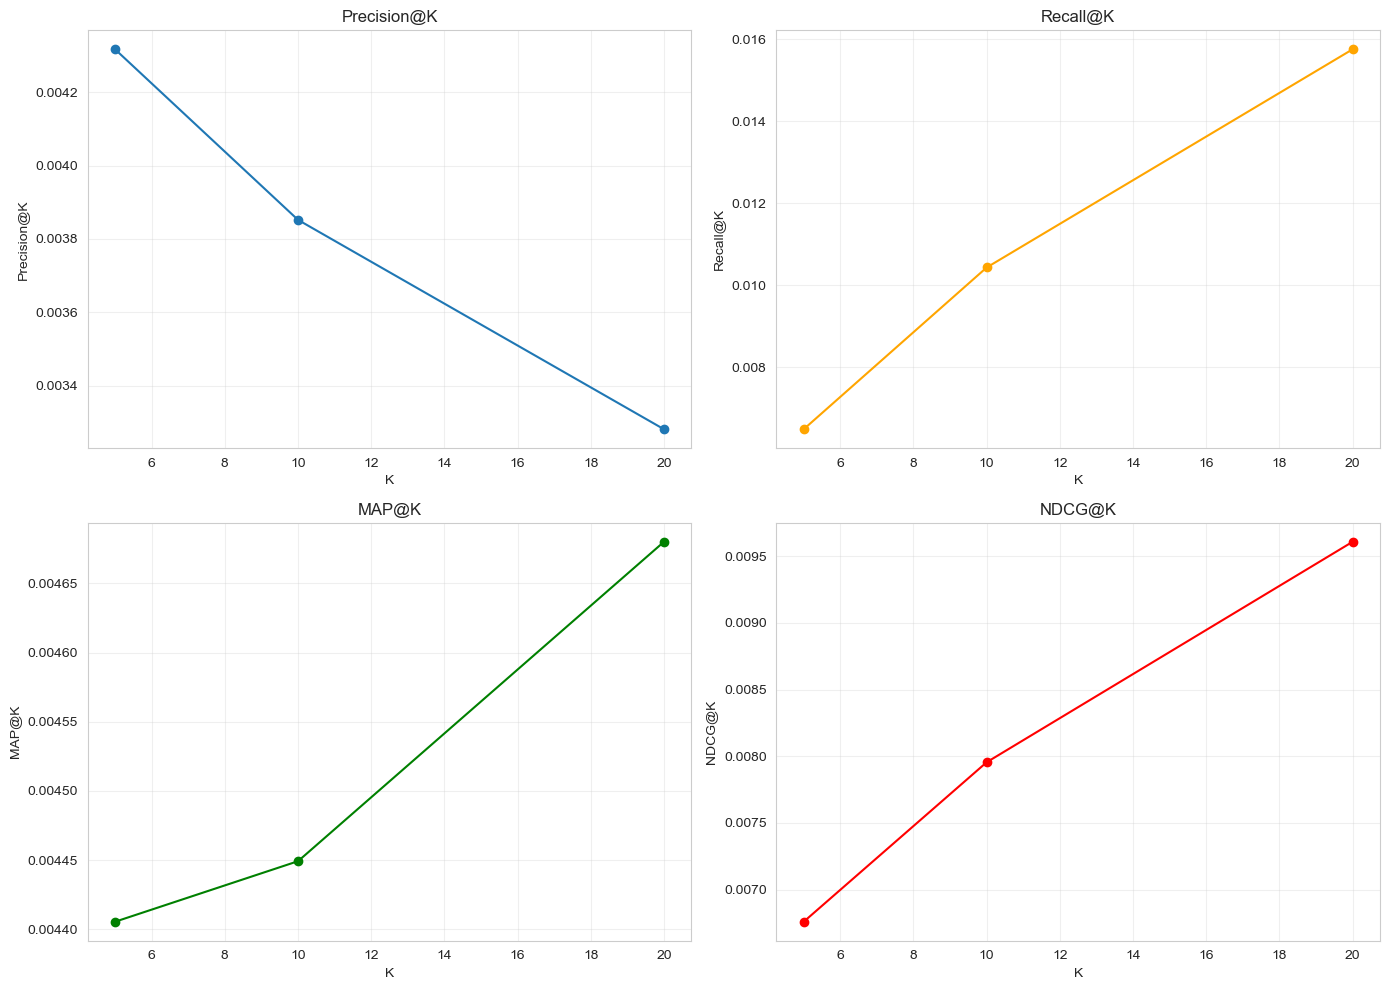

In [46]:
metrics_df = pd.DataFrame(results).T
metrics_df.index.name = "K"

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(metrics_df.index, metrics_df["precision"], marker="o")
axes[0, 0].set_xlabel("K"); axes[0, 0].set_ylabel("Precision@K")
axes[0, 0].set_title("Precision@K"); axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].plot(metrics_df.index, metrics_df["recall"], marker="o", color="orange")
axes[0, 1].set_xlabel("K"); axes[0, 1].set_ylabel("Recall@K")
axes[0, 1].set_title("Recall@K"); axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].plot(metrics_df.index, metrics_df["map"], marker="o", color="green")
axes[1, 0].set_xlabel("K"); axes[1, 0].set_ylabel("MAP@K")
axes[1, 0].set_title("MAP@K"); axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].plot(metrics_df.index, metrics_df["ndcg"], marker="o", color="red")
axes[1, 1].set_xlabel("K"); axes[1, 1].set_ylabel("NDCG@K")
axes[1, 1].set_title("NDCG@K"); axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
